# Training, Evaluation & Export
**Task:** Periapical Lesion Detection — Model Training & Inference  
**Model:** YOLOv11m  
**Prerequisites:** Run `01_data_preparation.ipynb` first to generate the YOLO dataset on Drive.

---
### Notebook Outline
1. Environment Setup
2. Google Drive Mounting & Path Configuration
3. Model Initialization & Training
4. Evaluation on Test Set
5. Visualization of Predictions
6. Error Analysis
7. Model Export
8. Inference Utility Function

## 1. Environment Setup

In [1]:
# ── Install dependencies ────────────────────────────────────────────────────
# YOLOv10 is included in ultralytics >= 8.2
!pip install ultralytics --quiet
!pip install Pillow matplotlib PyYAML --quiet

import os, shutil, random, time, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
import torch

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── GPU check ───────────────────────────────────────────────────────────────
print('=' * 55)
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('  No GPU found – switch runtime to GPU (Runtime → Change runtime type → T4)')
print('=' * 55)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.4 MB/s eta 0:00:00
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


## 2. Google Drive Mounting & Path Configuration

> These paths must match what was set in **Notebook 1**.

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ──  Must match Notebook 1 paths ─────────────────────────────────────────
WORK_DIR    = Path('/content/drive/MyDrive/Colab Notebooks')
DATASET_DIR = WORK_DIR / 'dataset'
yaml_path   = DATASET_DIR / 'data.yaml'
# ────────────────────────────────────────────────────────────────────────────

CLASS_DISPLAY = ['Periapical_Type3', 'Periapical_Type4', 'Periapical_Type5']
NC = len(CLASS_DISPLAY)

# ── Verify dataset exists ────────────────────────────────────────────────────
checks = {
    'data.yaml'   : yaml_path,
    'train images': DATASET_DIR / 'images' / 'train',
    'valid images': DATASET_DIR / 'images' / 'valid',
    'test images' : DATASET_DIR / 'images' / 'test',
    'train labels': DATASET_DIR / 'labels' / 'train',
}
print('Checking dataset paths from Notebook 1:')
all_ok = True
for name, p in checks.items():
    ok = p.exists()
    all_ok = all_ok and ok
    status = 'ok' if ok else ' MISSING'
    print(f'  {status}  {name:<15} : {p}')

if not all_ok:
    print('\n  Some paths are missing. Please run Notebook 1 first!')
else:
    # Count test images for later use
    test_imgs = (
        sorted((DATASET_DIR / 'images' / 'test').glob('*.jpg')) +
        sorted((DATASET_DIR / 'images' / 'test').glob('*.png'))
    )
    print(f'\n Dataset ready  |  Test images: {len(test_imgs)}')

Mounted at /content/drive
Checking dataset paths from Notebook 1:
  ok  data.yaml       : /content/drive/MyDrive/Colab Notebooks/dataset/data.yaml
  ok  train images    : /content/drive/MyDrive/Colab Notebooks/dataset/images/train
  ok  valid images    : /content/drive/MyDrive/Colab Notebooks/dataset/images/valid
  ok  test images     : /content/drive/MyDrive/Colab Notebooks/dataset/images/test
  ok  train labels    : /content/drive/MyDrive/Colab Notebooks/dataset/labels/train

 Dataset ready  |  Test images: 590


## 3. Model Initialization & Training

### Why YOLOv11m?
- **YOLOv11** eliminates NMS post-processing via dual-assignment training, reducing latency.
- **Medium (m) variant**: best accuracy/speed trade-off for Colab T4 (16 GB VRAM) at `imgsz=640`.
- **Transfer learning**: pretrained on COCO → faster convergence on this medical dataset.

In [3]:
from ultralytics import YOLO

MODEL_NAME = '/content/drive/MyDrive/Colab Notebooks/yolo11m.pt'
RUN_NAME   = 'periapical_det_v3'
PROJECT    = str(WORK_DIR / 'runs')

model = YOLO(MODEL_NAME)
print(f' Model loaded: {MODEL_NAME}')
print(f'   Parameters: {sum(p.numel() for p in model.model.parameters()) / 1e6:.1f} M')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
 Model loaded: /content/drive/MyDrive/Colab Notebooks/yolo11m.pt
   Parameters: 20.1 M


In [4]:
# ── Training ─────────────────────────────────────────────────────────────────
t_start = time.time()

results = model.train(
    data         = str(yaml_path),
    epochs       = 70,
    imgsz        = 640,
    batch        = 8,                 # reduce to 8 if OOM
    optimizer    = 'AdamW',
    lr0          = 0.001,
    cos_lr       = True,
    weight_decay = 0.0005,
    patience     = 20,                 # early stopping
    # ── Augmentation ────────────────────────────────────────────────────────
    mosaic       = 0.5,
    hsv_h        = 0.01,               # dental X-rays – subtle color aug
    hsv_s        = 0.3,
    hsv_v        = 0.4,
    degrees      = 5,
    translate    = 0.1,
    scale        = 0.2,
    fliplr       = 0.5,
    # ── Misc ────────────────────────────────────────────────────────────────
    plots        = True,
    save         = True,
    project      = PROJECT,
    name         = RUN_NAME,
    exist_ok     = True,
    seed         = SEED,
    workers      = 4,
    device       = 0,
    verbose      = True,
)

t_end = time.time()
elapsed = t_end - t_start
h, rem  = divmod(int(elapsed), 3600)
m, s    = divmod(rem, 60)
print(f'\n  Total training time: {h:02d}h {m:02d}m {s:02d}s')

# ── Key metrics ──────────────────────────────────────────────────────────────
try:
    metrics = results.results_dict
    print('\n Final Training Metrics:')
    print(f"   mAP50      (box) : {metrics.get('metrics/mAP50(B)', 'N/A'):.4f}")
    print(f"   mAP50-95   (box) : {metrics.get('metrics/mAP50-95(B)', 'N/A'):.4f}")
    print(f"   Precision        : {metrics.get('metrics/precision(B)', 'N/A'):.4f}")
    print(f"   Recall           : {metrics.get('metrics/recall(B)', 'N/A'):.4f}")
    print(f"   Box loss         : {metrics.get('train/box_loss', 'N/A'):.4f}")
    print(f"   Cls loss         : {metrics.get('train/cls_loss', 'N/A'):.4f}")
    print(f"   DFL loss         : {metrics.get('train/dfl_loss', 'N/A'):.4f}")
except Exception as e:
    print(f'   (Could not parse metrics dict: {e})')

BEST_PT = Path(PROJECT) / RUN_NAME / 'weights' / 'best.pt'
print(f'\n Best model saved at: {BEST_PT}')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/dataset/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.3, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Colab Notebooks/yolo11m.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=periapical_det_v3, nbs=64, nms=False, opset=

## 4. Evaluation on Test Set

In [5]:
# ── Load best weights ────────────────────────────────────────────────────────
best_model = YOLO(str(BEST_PT))

test_metrics = best_model.val(
    data     = str(yaml_path),
    split    = 'test',
    imgsz    = 640,
    batch    = 16,
    device   = 0,
    plots    = True,
    save_json= True,
    project  = PROJECT,
    name     = RUN_NAME + '_test_eval',
    exist_ok = True,
    verbose  = True,
)

print('\n Test Set Evaluation:')
print(f'   mAP50 (box)    : {test_metrics.box.map50:.4f}')
print(f'   mAP50-95 (box) : {test_metrics.box.map:.4f}')
print(f'   Precision      : {test_metrics.box.mp:.4f}')
print(f'   Recall         : {test_metrics.box.mr:.4f}')

print('\n   Per-class AP50 (detection):')
try:
    per_class_ap50 = test_metrics.box.ap50
    for i, name in enumerate(CLASS_DISPLAY):
        print(f'     [{i}] {name:<25} AP50={per_class_ap50[i]:.4f}')
except Exception as e:
    print(f'   (Per-class metrics unavailable: {e})')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,032,345 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 0.4±0.1 MB/s, size: 191.6 KB)
val: Scanning /content/drive/MyDrive/Colab Notebooks/dataset/labels/test... 590 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 590/590 2.7it/s 3:39
val: New cache created: /content/drive/MyDrive/Colab Notebooks/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 1.8it/s 21.1s
                   all        590       1013      0.538       0.52      0.483      0.221
      Periapical_Type3        426        643      0.598      0.518      0.538      0.215
      Periapical_Type4        213        258      0.554      0.488      0.502      0.249
      Periapical_Type5        107        112      0.464      0.554      0.409      0.198
Speed: 0.9ms preprocess, 1

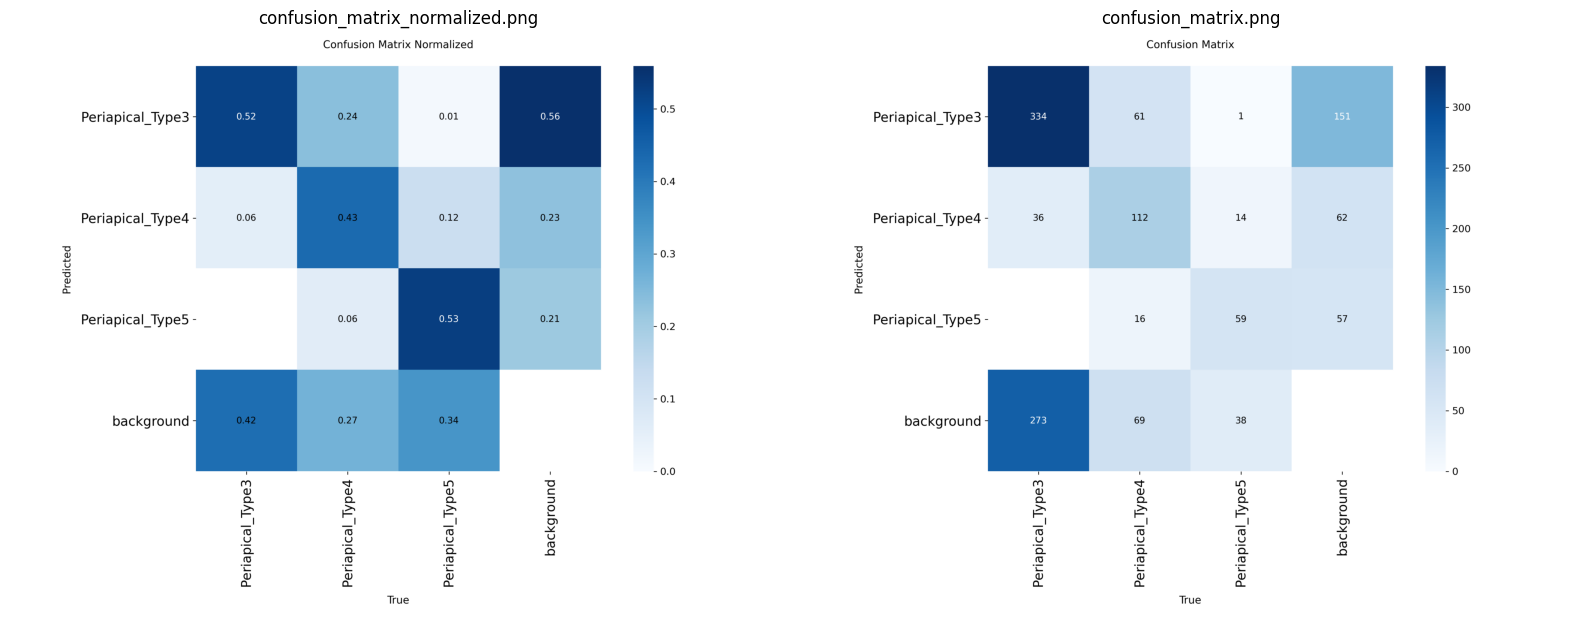

In [6]:
# ── Display confusion matrix saved by val() ──────────────────────────────────
EVAL_DIR = Path(PROJECT) / (RUN_NAME + '_test_eval')
cm_imgs  = list(EVAL_DIR.glob('confusion_matrix*.png'))
if cm_imgs:
    fig, axes = plt.subplots(1, len(cm_imgs), figsize=(8 * len(cm_imgs), 7))
    if len(cm_imgs) == 1:
        axes = [axes]
    for ax, p in zip(axes, cm_imgs):
        ax.imshow(plt.imread(p))
        ax.axis('off')
        ax.set_title(p.name)
    plt.tight_layout()
    plt.show()
else:
    print('Confusion matrix image not found – check', EVAL_DIR)

## 5. Visualization of Predictions on Test Images

Test images found: 590


/tmp/ipykernel_440/4045524051.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('tab10', len(class_names))


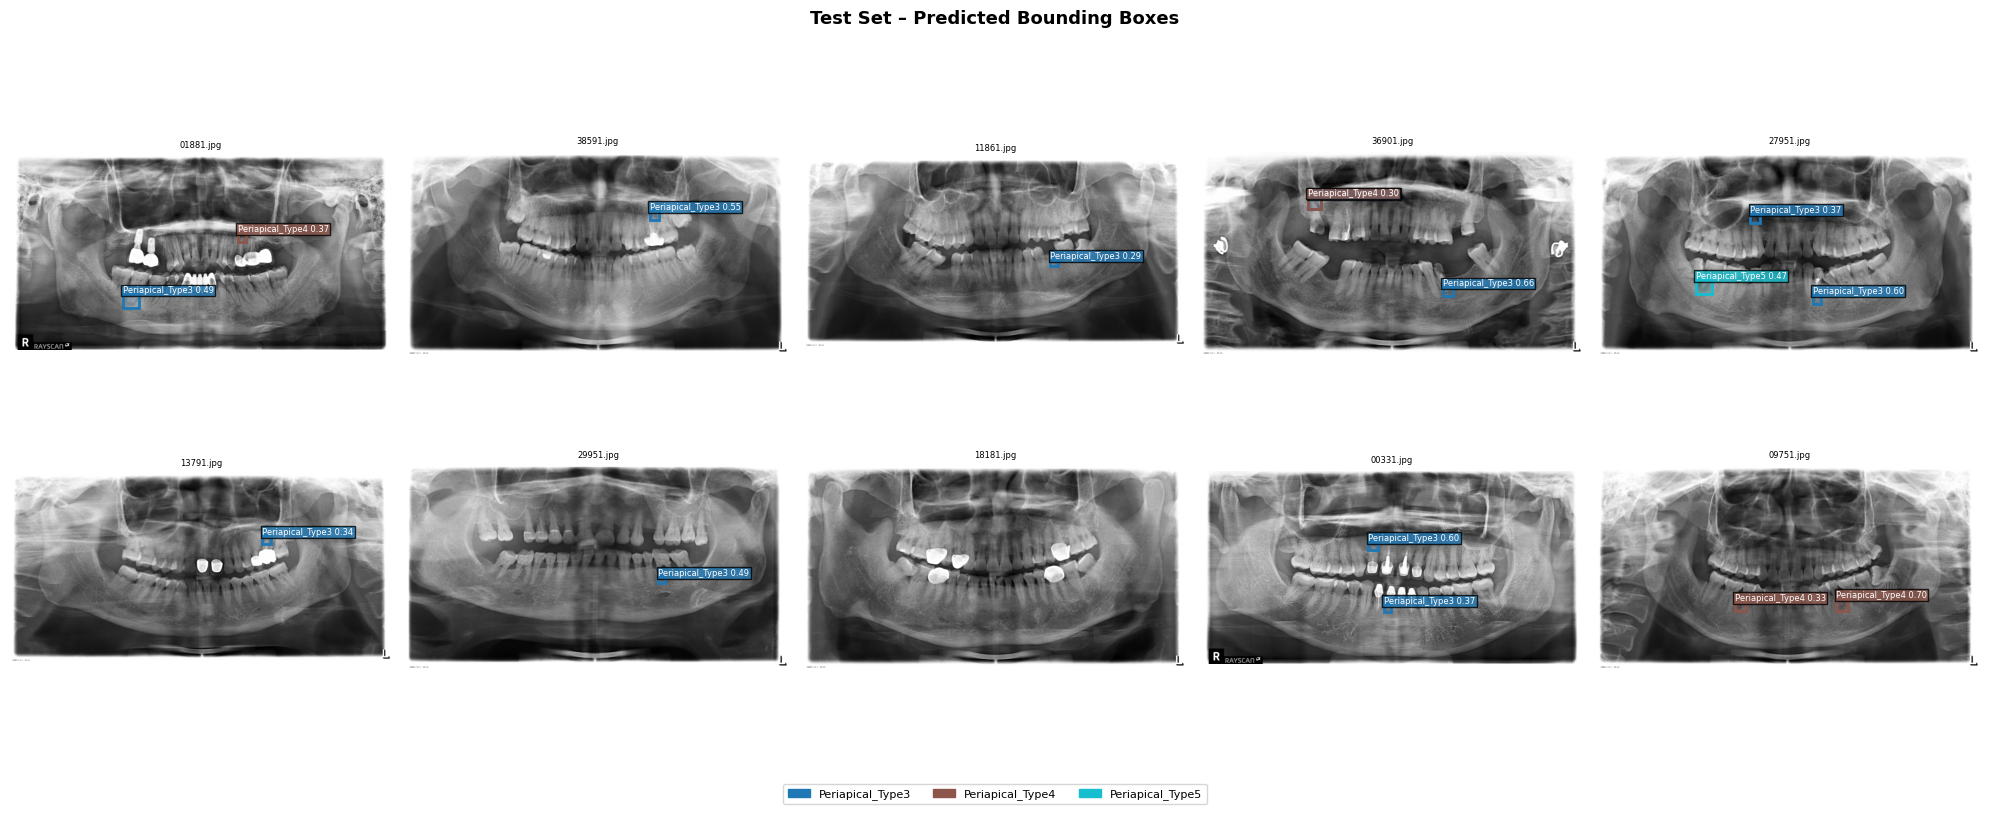

In [7]:
def plot_predictions(model, img_paths: list, class_names: list,
                     conf: float = 0.25, n: int = 10,
                     title: str = 'Predictions'):
    """Run inference and visualise predicted bounding boxes."""
    samples = random.sample(img_paths, min(n, len(img_paths)))
    cols    = 5
    rows    = math.ceil(len(samples) / cols)
    cmap    = plt.cm.get_cmap('tab10', len(class_names))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = np.array(axes).flatten()

    for ax, img_path in zip(axes[:len(samples)], samples):
        preds = model.predict(source=str(img_path), conf=conf,
                              verbose=False, imgsz=640)
        r   = preds[0]
        img = np.array(Image.open(img_path).convert('RGB'))

        ax.imshow(img)
        ax.set_title(Path(img_path).name, fontsize=6)
        ax.axis('off')

        if r.boxes is not None and len(r.boxes):
            for box, cls_id, score in zip(
                    r.boxes.xyxy.cpu().numpy(),
                    r.boxes.cls.cpu().numpy().astype(int),
                    r.boxes.conf.cpu().numpy()):
                color = cmap(cls_id)
                x1, y1, x2, y2 = box
                rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                           linewidth=2, edgecolor=color,
                                           facecolor=(*color[:3], 0.15))
                ax.add_patch(rect)
                ax.text(x1, y1 - 4,
                        f'{class_names[cls_id]} {score:.2f}',
                        color='white', fontsize=6,
                        bbox=dict(facecolor=color, alpha=0.8, pad=1))

    for ax in axes[len(samples):]:
        ax.axis('off')

    legend = [mpatches.Patch(color=cmap(i), label=class_names[i])
              for i in range(len(class_names))]
    fig.legend(handles=legend, loc='lower center', ncol=len(class_names),
               fontsize=8, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ── Reload test images list ──────────────────────────────────────────────────
test_imgs = (
    sorted((DATASET_DIR / 'images' / 'test').glob('*.jpg')) +
    sorted((DATASET_DIR / 'images' / 'test').glob('*.png'))
)
print(f'Test images found: {len(test_imgs)}')

plot_predictions(best_model, test_imgs, CLASS_DISPLAY,
                 conf=0.25, n=10, title='Test Set – Predicted Bounding Boxes')

/tmp/ipykernel_440/3308670927.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('tab10', len(class_names))


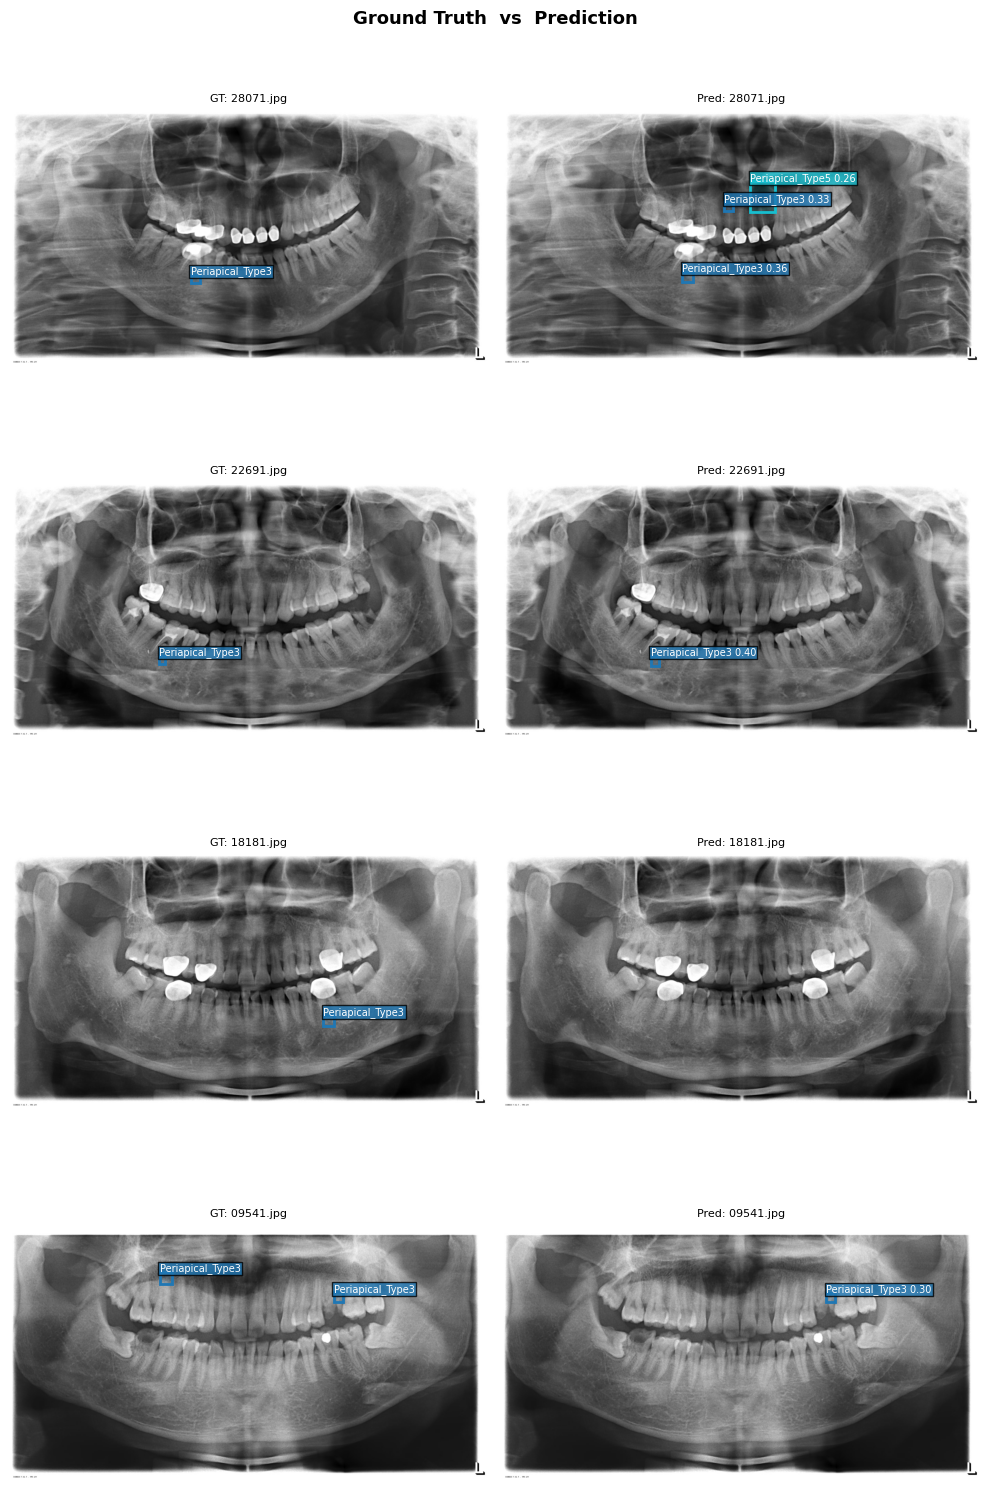

In [8]:
# ── Ground-truth vs Prediction side-by-side for 4 images ─────────────────────
def plot_gt_vs_pred(model, img_paths: list,
                    lbl_dir: Path, class_names: list,
                    conf: float = 0.25, n: int = 4):
    samples = random.sample(img_paths, min(n, len(img_paths)))
    cmap    = plt.cm.get_cmap('tab10', len(class_names))

    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))

    for row, img_path in enumerate(samples):
        img  = np.array(Image.open(img_path).convert('RGB'))
        h, w = img.shape[:2]

        # Ground truth
        ax_gt = axes[row, 0]
        ax_gt.imshow(img)
        ax_gt.set_title(f'GT: {img_path.name}', fontsize=8)
        ax_gt.axis('off')
        lbl_p = lbl_dir / (img_path.stem + '.txt')
        if lbl_p.exists():
            for line in lbl_p.read_text().strip().splitlines():
                parts = line.split()
                if len(parts) != 5:
                    continue
                cls_idx = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:])
                x1 = (xc - bw/2) * w
                y1 = (yc - bh/2) * h
                color = cmap(cls_idx)
                rect  = mpatches.Rectangle((x1, y1), bw*w, bh*h,
                                            linewidth=2, edgecolor=color,
                                            facecolor=(*color[:3], 0.15))
                ax_gt.add_patch(rect)
                ax_gt.text(x1, y1 - 4, class_names[cls_idx],
                           color='white', fontsize=7,
                           bbox=dict(facecolor=color, alpha=0.8, pad=1))

        # Prediction
        ax_pr = axes[row, 1]
        ax_pr.imshow(img)
        ax_pr.set_title(f'Pred: {img_path.name}', fontsize=8)
        ax_pr.axis('off')
        preds = model.predict(source=str(img_path), conf=conf, verbose=False)
        r     = preds[0]
        if r.boxes is not None and len(r.boxes):
            for box, cls_id, score in zip(
                    r.boxes.xyxy.cpu().numpy(),
                    r.boxes.cls.cpu().numpy().astype(int),
                    r.boxes.conf.cpu().numpy()):
                color = cmap(cls_id)
                x1, y1, x2, y2 = box
                rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                           linewidth=2, edgecolor=color,
                                           facecolor=(*color[:3], 0.15))
                ax_pr.add_patch(rect)
                ax_pr.text(x1, y1 - 4,
                           f'{class_names[cls_id]} {score:.2f}',
                           color='white', fontsize=7,
                           bbox=dict(facecolor=color, alpha=0.8, pad=1))

    plt.suptitle('Ground Truth  vs  Prediction', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_gt_vs_pred(best_model, test_imgs,
                lbl_dir     = DATASET_DIR / 'labels' / 'test',
                class_names = CLASS_DISPLAY,
                conf        = 0.25,
                n           = 4)

## 6. Error Analysis

1. **False Positives (FP)**
2. **False Negatives (FN)** 
3. **Low-confidence TPs**

In [9]:
def iou_boxes(b1, b2):
    """IoU between two xyxy boxes."""
    x1 = max(b1[0], b2[0]);  y1 = max(b1[1], b2[1])
    x2 = min(b1[2], b2[2]);  y2 = min(b1[3], b2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    a1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    union = a1 + a2 - inter
    return inter / union if union > 0 else 0.0


def collect_error_cases(model, img_paths, lbl_dir, class_names,
                         conf=0.25, iou_thr=0.5, max_cases=20):
    fp_cases, fn_cases, lc_cases = [], [], []

    for img_path in img_paths:
        img  = Image.open(img_path).convert('RGB')
        w, h = img.size

        lbl_p    = lbl_dir / (img_path.stem + '.txt')
        gt_boxes = []
        if lbl_p.exists():
            for line in lbl_p.read_text().strip().splitlines():
                parts = line.split()
                if len(parts) != 5:
                    continue
                cls_idx = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:])
                x1 = (xc - bw/2) * w
                y1 = (yc - bh/2) * h
                x2 = (xc + bw/2) * w
                y2 = (yc + bh/2) * h
                gt_boxes.append({'cls': cls_idx, 'box': [x1, y1, x2, y2]})

        result    = model.predict(source=str(img_path), conf=conf, verbose=False)[0]
        pred_boxes = []
        if result.boxes is not None:
            for box, cls_id, score in zip(
                    result.boxes.xyxy.cpu().numpy(),
                    result.boxes.cls.cpu().numpy().astype(int),
                    result.boxes.conf.cpu().numpy()):
                pred_boxes.append({'cls': cls_id, 'box': box.tolist(), 'conf': score})

        matched_gt   = set()
        matched_pred = set()

        for pi, p in enumerate(pred_boxes):
            for gi, g in enumerate(gt_boxes):
                if gi in matched_gt:
                    continue
                if iou_boxes(p['box'], g['box']) >= iou_thr:
                    matched_gt.add(gi)
                    matched_pred.add(pi)
                    if p['conf'] < 0.5 and len(lc_cases) < max_cases:
                        lc_cases.append((img_path, pred_boxes, gt_boxes))
                    break

        if any(pi not in matched_pred for pi in range(len(pred_boxes))):
            if len(fp_cases) < max_cases:
                fp_cases.append((img_path, pred_boxes, gt_boxes))

        if any(gi not in matched_gt for gi in range(len(gt_boxes))):
            if len(fn_cases) < max_cases:
                fn_cases.append((img_path, pred_boxes, gt_boxes))

    return fp_cases, fn_cases, lc_cases


print('Collecting error cases (this may take a few minutes)...')
fp_cases, fn_cases, lc_cases = collect_error_cases(
    best_model, test_imgs[:200],
    lbl_dir     = DATASET_DIR / 'labels' / 'test',
    class_names = CLASS_DISPLAY,
    conf        = 0.25,
    iou_thr     = 0.5,
    max_cases   = 20,
)
print(f'  False Positives  : {len(fp_cases)}')
print(f'  False Negatives  : {len(fn_cases)}')
print(f'  Low-conf TPs     : {len(lc_cases)}')

  False Positives  : 20
  False Negatives  : 20
  Low-conf TPs     : 20


/tmp/ipykernel_440/2749326581.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('tab10', len(class_names))


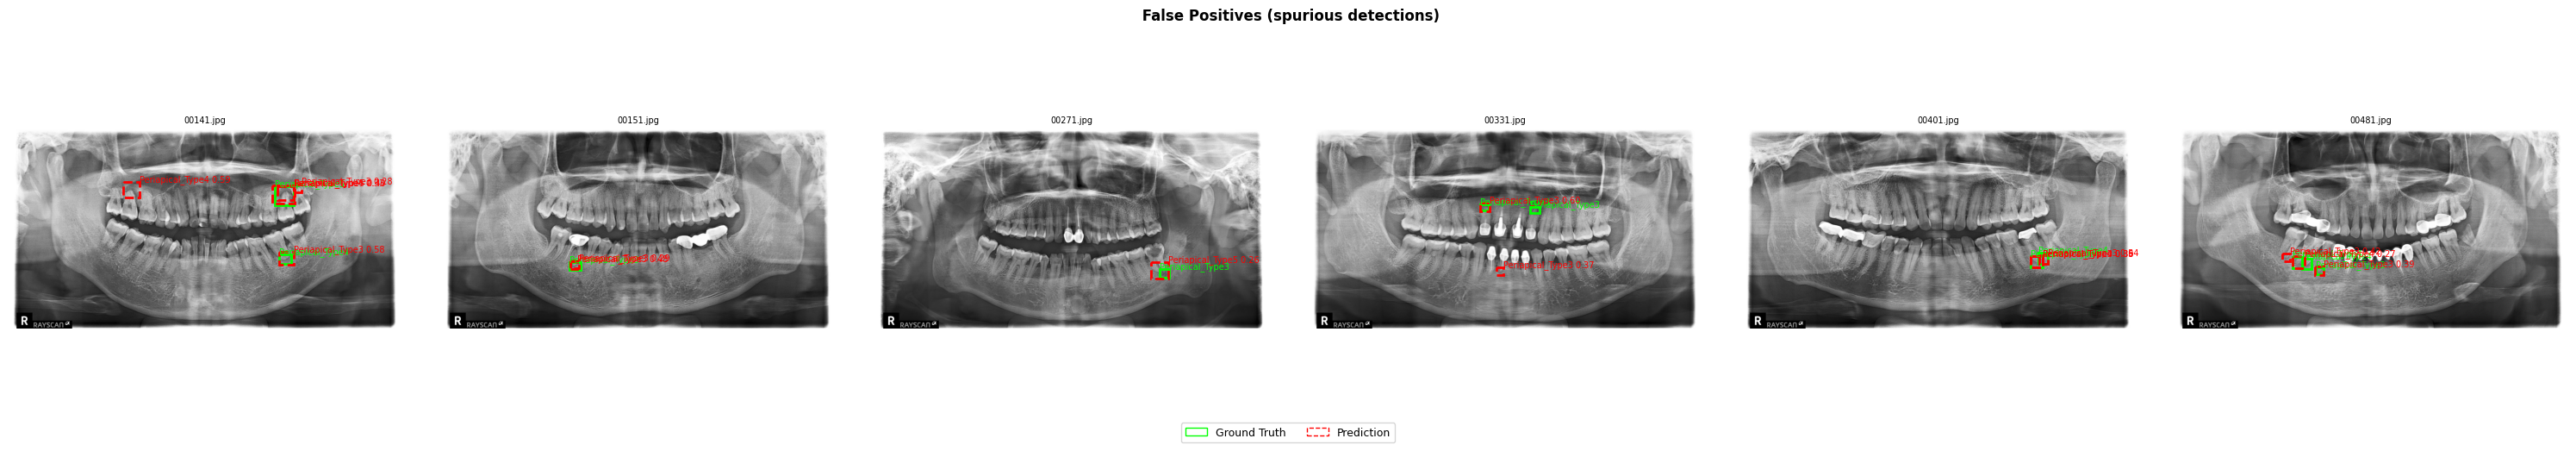

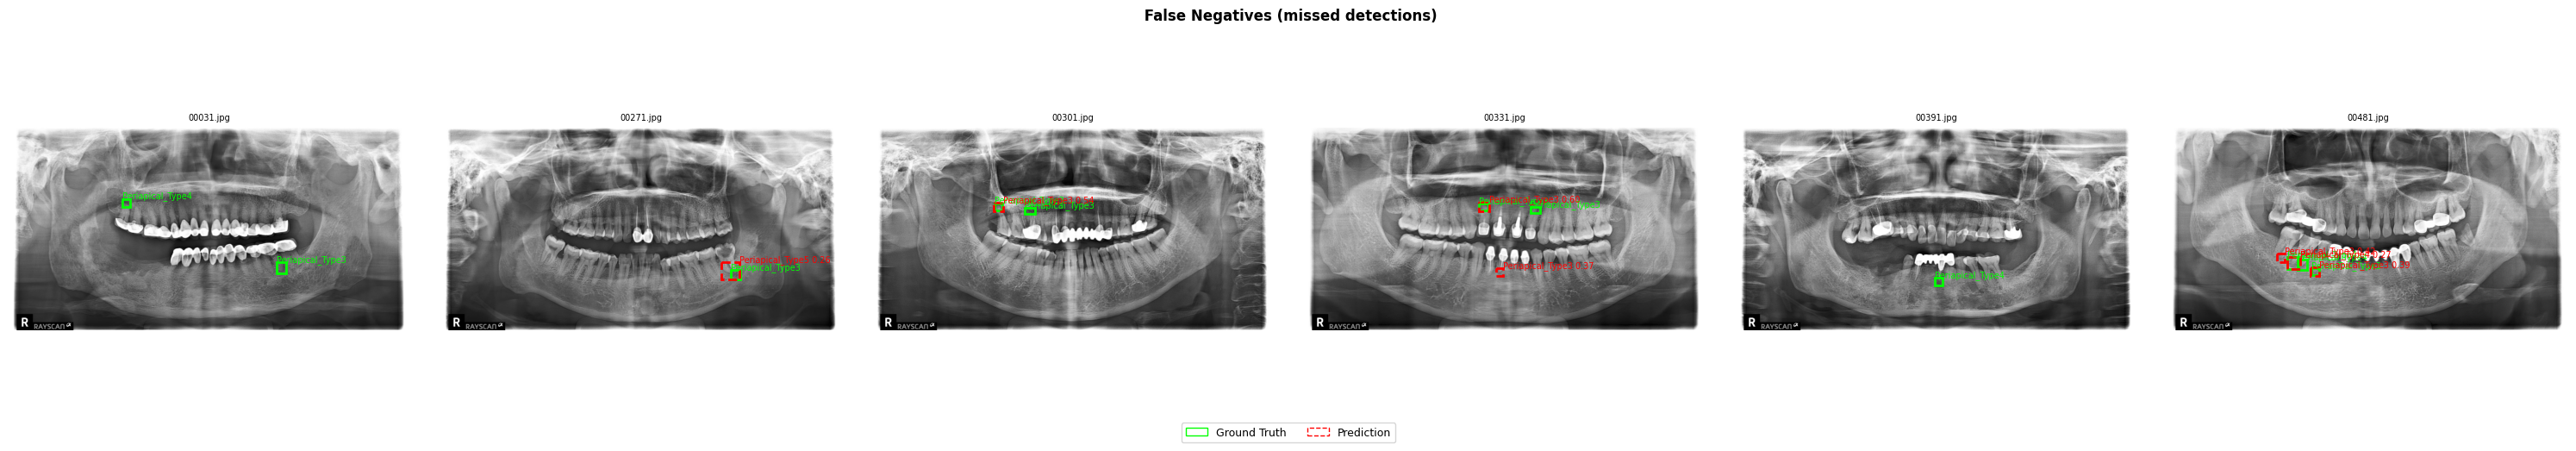

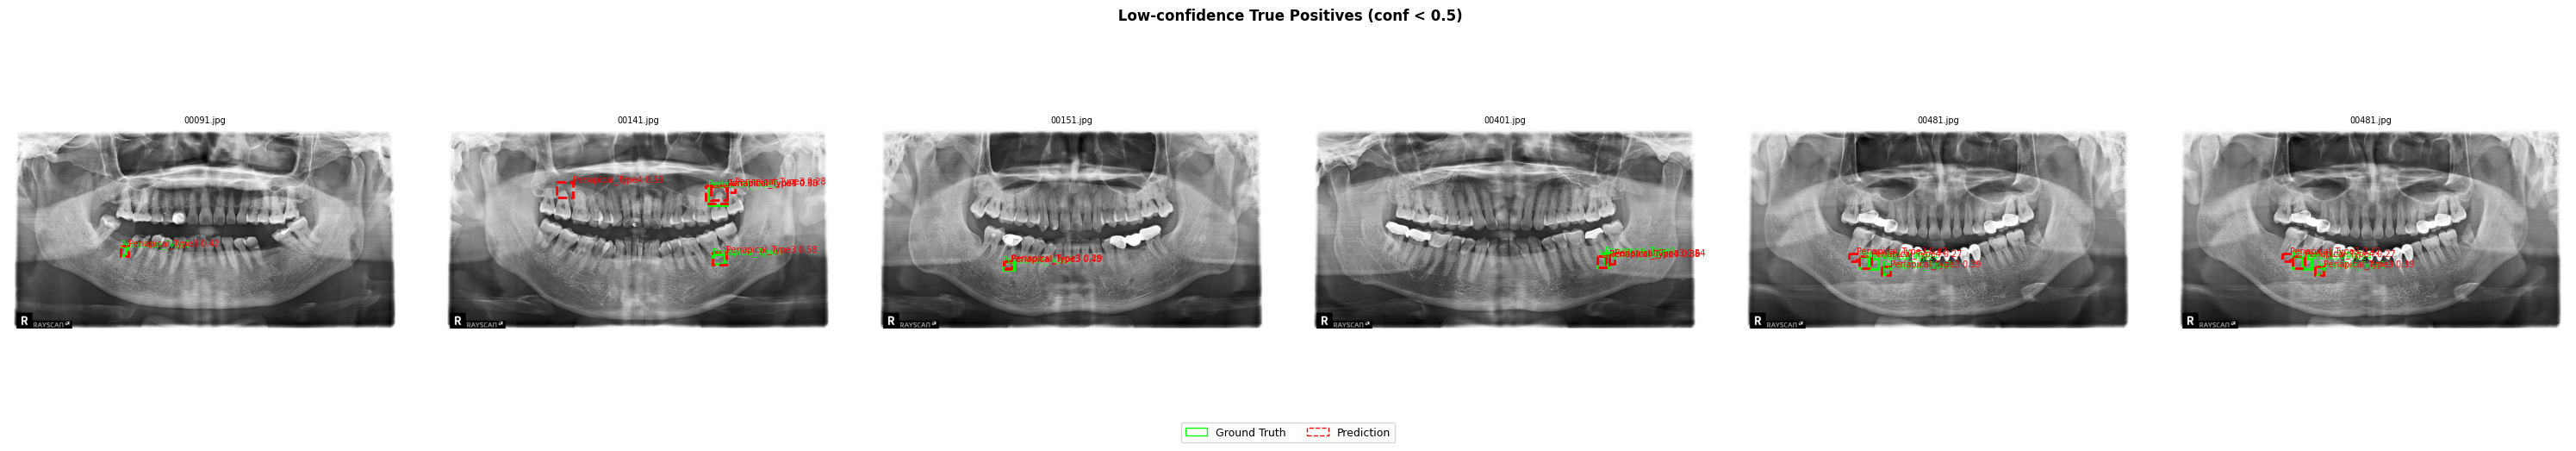

In [10]:
def show_error_cases(cases, class_names, title='Error Cases', n=6):
    if not cases:
        print(f'No cases found for: {title}')
        return
    samples = cases[:n]
    cmap    = plt.cm.get_cmap('tab10', len(class_names))
    fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))
    if len(samples) == 1:
        axes = [axes]

    for ax, (img_path, preds, gts) in zip(axes, samples):
        img = np.array(Image.open(img_path).convert('RGB'))
        ax.imshow(img)
        ax.set_title(Path(img_path).name, fontsize=7)
        ax.axis('off')
        for g in gts:
            x1, y1, x2, y2 = g['box']
            rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                       linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, class_names[g['cls']], color='lime', fontsize=7)
        for p in preds:
            x1, y1, x2, y2 = p['box']
            rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                       linewidth=2, edgecolor='red',
                                       facecolor='none', linestyle='--')
            ax.add_patch(rect)
            ax.text(x2, y1 - 4, f"{class_names[p['cls']]} {p['conf']:.2f}",
                    color='red', fontsize=7)

    legend = [
        mpatches.Patch(edgecolor='lime', facecolor='none', label='Ground Truth'),
        mpatches.Patch(edgecolor='red',  facecolor='none', label='Prediction', linestyle='--'),
    ]
    fig.legend(handles=legend, loc='lower center', ncol=2, fontsize=9,
               bbox_to_anchor=(0.5, -0.04))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


show_error_cases(fp_cases, CLASS_DISPLAY, title=' False Positives (spurious detections)')
show_error_cases(fn_cases, CLASS_DISPLAY, title=' False Negatives (missed detections)')
show_error_cases(lc_cases, CLASS_DISPLAY, title=' Low-confidence True Positives (conf < 0.5)')

## 7. Model Export

In [11]:
DRIVE_DATASET_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/yolo-periapical/dataset')

# ── Export to ONNX ───────────────────────────────────────────────────────────
onnx_path = best_model.export(format='onnx', imgsz=640, dynamic=False, simplify=True)
print(f' ONNX exported  : {onnx_path}')

# ── Export to TorchScript ────────────────────────────────────────────────────
ts_path = best_model.export(format='torchscript', imgsz=640)
print(f' TorchScript exported: {ts_path}')

# ── Copy exports to Google Drive ─────────────────────────────────────────────
export_drive = DRIVE_DATASET_ROOT / 'exports'
export_drive.mkdir(parents=True, exist_ok=True)

for p in [BEST_PT, Path(str(onnx_path)), Path(str(ts_path))]:
    if p.exists():
        shutil.copy2(p, export_drive / p.name)
        print(f'   Copied {p.name} → {export_drive}')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/Colab Notebooks/runs/periapical_det_v3/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (38.6 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 267ms
Prepared 4 packages in 8.08s
Installed 4 packages in 303ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.0
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 9.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export succ

## 8. Inference Utility Function

/tmp/ipykernel_440/193194954.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(CLASS_DISPLAY))



  Image  : /content/drive/MyDrive/Colab Notebooks/dataset/images/test/13281.jpg
  Objects detected: 1
  [1] Periapical_Type3           conf=0.549  box=[704,870,775,936]


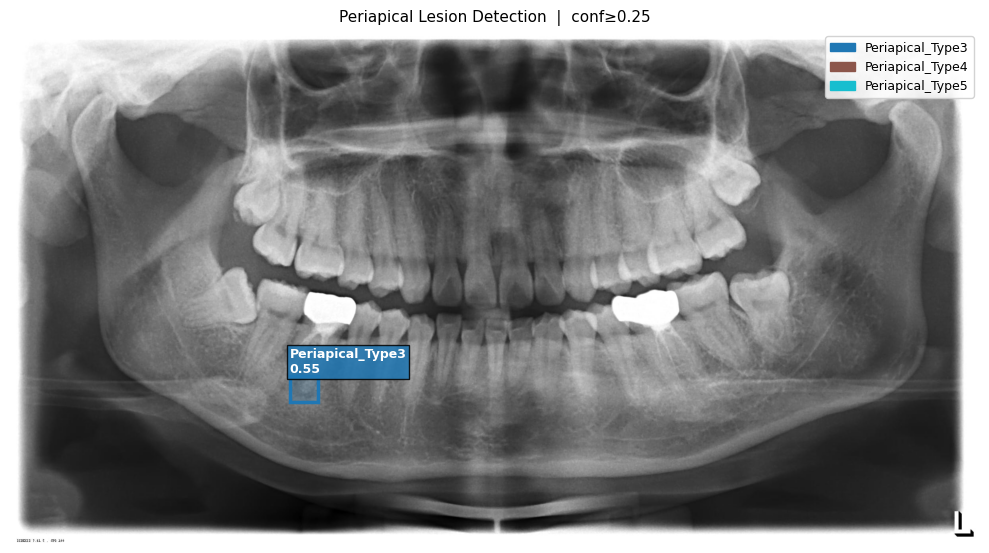

In [12]:
def predict_image(image_path: str,
                  conf: float = 0.25,
                  model_path: str = None) -> None:
    """
    Run periapical lesion detection on a single dental X-ray and display results.

    Parameters
    ----------
    image_path : str or Path – path to the input image
    conf       : float       – confidence threshold (default 0.25)
    model_path : str or None – path to best.pt; auto-detected if None
    """
    if model_path is None:
        model_path = str(BEST_PT)
    inf_model = YOLO(model_path)

    results = inf_model.predict(
        source  = str(image_path),
        conf    = conf,
        imgsz   = 640,
        verbose = False,
    )
    r   = results[0]
    img = np.array(Image.open(image_path).convert('RGB'))
    cmap = plt.cm.get_cmap('tab10', len(CLASS_DISPLAY))

    print(f"\n{'='*55}")
    print(f'  Image  : {image_path}')
    print(f'  Objects detected: {len(r.boxes) if r.boxes else 0}')
    print(f"{'='*55}")

    if r.boxes is not None and len(r.boxes):
        for i, (cls_id, score, box) in enumerate(
                zip(r.boxes.cls.cpu().numpy().astype(int),
                    r.boxes.conf.cpu().numpy(),
                    r.boxes.xyxy.cpu().numpy())):
            print(f'  [{i+1}] {CLASS_DISPLAY[cls_id]:<25}  conf={score:.3f}  '
                  f'box=[{box[0]:.0f},{box[1]:.0f},{box[2]:.0f},{box[3]:.0f}]')
    else:
        print('  No lesions detected at this confidence threshold.')

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Periapical Lesion Detection  |  conf≥{conf}', fontsize=11)

    if r.boxes is not None and len(r.boxes):
        for box, cls_id, score in zip(
                r.boxes.xyxy.cpu().numpy(),
                r.boxes.cls.cpu().numpy().astype(int),
                r.boxes.conf.cpu().numpy()):
            color = cmap(cls_id)
            x1, y1, x2, y2 = box
            rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                       linewidth=2.5, edgecolor=color,
                                       facecolor=(*color[:3], 0.20))
            ax.add_patch(rect)
            label = f'{CLASS_DISPLAY[cls_id]}\n{score:.2f}'
            ax.text(x1, y1 - 6, label, color='white', fontsize=9,
                    fontweight='bold',
                    bbox=dict(facecolor=color, alpha=0.85, pad=2))

    legend = [mpatches.Patch(color=cmap(i), label=CLASS_DISPLAY[i])
              for i in range(len(CLASS_DISPLAY))]
    ax.legend(handles=legend, loc='upper right', fontsize=9, framealpha=0.85)
    plt.tight_layout()
    plt.show()


# ── Demo: run on a random test image ────────────────────────────────────────
if test_imgs:
    demo_img = random.choice(test_imgs)
    predict_image(str(demo_img), conf=0.25)

##  Summary

| Stage | Details | Status |
|---|---|---|
| Model (YOLOv11m) Initialization | Pretrained on COCO | ✅ |
| Training | 50 epochs · AdamW · cos_lr | ✅ |
| Test Evaluation + Confusion Matrix | mAP50, Precision, Recall | ✅ |
| Prediction Visualization | Bounding box overlay | ✅ |
| Error Analysis | FP / FN / Low-conf TP | ✅ |
| Export | ONNX + TorchScript | ✅ |
| `predict_image()` Utility | Single image inference | ✅ |


### Class Mapping Reference
| XML Class | YOLO Index | Display Name |
|---|---|---|
| `'3'` | 0 | Periapical_Type3 |
| `'4'` | 1 | Periapical_Type4 |
| `'5'` | 2 | Periapical_Type5 |